In [1]:
from syllable_database import *

In [2]:
bird_path = os.path.join('/Volumes', 'Extreme SSD', 'evsong test', 'or18or24')
db = SyllableDatabase(bird_path)
df = db.load_database()

In [3]:
df

,bird_name,clustering_labels,duration_ms,end_time_ms,f0_max,f0_mean,f0_min,f0_range,f0_std,f0_voiced_fraction,...,cluster_rank62_unknown_n5_d0p5_cs20_s15_euclidean,cluster_rank63_unknown_n5_d0p01_cs60_s15_euclidean,cluster_rank64_unknown_n5_d0p1_cs60_s15_euclidean,cluster_rank65_unknown_n5_d0p1_cs20_s15_euclidean,cluster_rank66_unknown_n50_d0p01_cs20_s15_euclidean,cluster_rank67_unknown_n50_d0p01_cs60_s15_euclidean,cluster_rank68_unknown_n50_d0p01_cs5_s15_euclidean,cluster_rank69_unknown_n5_d0p5_cs60_s15_euclidean,cluster_rank70_unknown_n5_d0p5_cs60_s5_euclidean,cluster_rank71_unknown_n5_d0p5_cs20_s5_euclidean
0,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 0...",46.25000,53.31250,2113.598097,2113.598097,2113.598097,0.000000,0.000000,1.000000,...,-1,0,-1,-1,0,0,0,-1,-1,1
1,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 1...",85.06250,221.06250,NaN,NaN,NaN,NaN,NaN,0.000000,...,2,-1,-1,2,1,1,1,2,1,1
2,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 0...",56.78125,374.50000,2265.298350,2255.569233,2226.381881,38.916470,16.851326,1.000000,...,-1,-1,-1,-1,0,0,0,-1,-1,1
3,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 0...",66.12500,534.15625,6749.127800,6656.415282,6594.977508,154.150292,52.307935,1.000000,...,2,-1,-1,-1,0,0,0,1,0,1
4,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 0...",70.25000,664.62500,6867.100476,6811.864932,6788.225099,78.875376,31.538791,1.000000,...,2,1,-1,2,1,1,1,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1449,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 2...",96.87500,4397.59375,2125.842046,2116.046886,2113.598097,12.243949,4.897580,0.714286,...,2,-1,-1,1,1,1,1,-1,-1,1
1450,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 1...",74.46875,4509.68750,1767.080470,1704.242771,1503.197326,263.883143,102.393417,1.000000,...,2,2,2,2,1,1,1,2,1,1
1451,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 1...",89.84375,4609.31250,3130.444967,3080.230310,2954.746592,175.698375,60.316205,1.000000,...,2,-1,-1,-1,1,1,1,-1,-1,1
1452,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 2...",100.12500,4809.62500,2138.156924,2125.856232,2113.598097,24.558827,7.766202,0.714286,...,2,-1,-1,0,1,1,1,-1,1,1


In [4]:
import json
import pandas as pd
from pathlib import Path

def explore_analysis_files(bird_path: str):
    """
    Quick exploration of the analysis JSON files to see what's actually in them.
    """
    database_dir = Path(bird_path) / 'data' / 'syllable_database'

    if not database_dir.exists():
        print(f"No database directory found at {database_dir}")
        return

    # Find all JSON files
    json_files = list(database_dir.glob("*.json"))

    if not json_files:
        print("No JSON analysis files found")
        return

    print(f"Found {len(json_files)} analysis files:")

    for json_file in json_files:
        print(f"\n{'='*50}")
        print(f"File: {json_file.name}")
        print(f"{'='*50}")

        try:
            with open(json_file, 'r') as f:
                data = json.load(f)

            # Show the top-level structure
            print("Top-level keys:")
            for key in data.keys():
                print(f"  - {key}: {type(data[key])}")

            # If it's a clustering analysis, show key metrics
            if 'clustering_quality' in data:
                quality = data['clustering_quality']
                if 'cluster_separation' in quality:
                    sep = quality['cluster_separation']
                    print(f"\nClustering Quality Summary:")
                    print(f"  Method: {quality.get('clustering_method', 'unknown')}")
                    print(f"  Clusters: {quality.get('n_clusters', 'unknown')}")
                    print(f"  Syllables: {quality.get('n_syllables', 'unknown')}")
                    print(f"  Mean separation ratio: {sep.get('mean_separation_ratio', 'unknown'):.3f}")

            # If it has manual comparison
            if 'manual_comparison' in data:
                comp = data['manual_comparison']
                if 'comparison_summary' in comp:
                    summary = comp['comparison_summary']
                    print(f"\nManual vs Clustering:")
                    print(f"  Manual separation: {summary.get('manual_mean_separation', 'unknown'):.3f}")
                    print(f"  Clustering separation: {summary.get('clustering_mean_separation', 'unknown'):.3f}")
                    print(f"  Relative quality: {summary.get('relative_quality', 'unknown'):.3f}")

            # If it's a database summary
            if 'total_syllables' in data:
                print(f"\nDatabase Summary:")
                print(f"  Bird: {data.get('bird_name', 'unknown')}")
                print(f"  Total syllables: {data.get('total_syllables', 'unknown')}")
                if 'manual_labels' in data:
                    ml = data['manual_labels']
                    print(f"  Manual labels: {ml.get('n_labeled_syllables', 0)} syllables, {ml.get('n_unique_labels', 0)} unique labels")
                if 'clustering_methods' in data:
                    print(f"  Clustering methods: {len(data['clustering_methods'])}")

        except Exception as e:
            print(f"Error reading {json_file.name}: {e}")

In [5]:
# Usage
explore_analysis_files(bird_path)

Found 3 analysis files:

File: feature_params.json
Top-level keys:
  - hop_length: <class 'int'>
  - n_fft: <class 'int'>
  - n_mfcc: <class 'int'>
  - spectral_rolloff_percent: <class 'float'>
  - f0_method: <class 'str'>
  - f0_fmin: <class 'float'>
  - f0_fmax: <class 'float'>
  - apply_preemphasis: <class 'bool'>
  - preemphasis_coeff: <class 'float'>

File: database_summary_20260211_174936.json
Top-level keys:
  - bird_name: <class 'str'>
  - total_syllables: <class 'int'>
  - unique_songs: <class 'int'>
  - duration_stats: <class 'dict'>
  - manual_labels: <class 'dict'>
  - clustering_methods: <class 'list'>
  - feature_coverage: <class 'dict'>

Database Summary:
  Bird: or18or24
  Total syllables: 1454
  Manual labels: 1088 syllables, 8 unique labels
  Clustering methods: 72

File: top_clustering_analysis_20260211_174943.json
Top-level keys:
  - rank0_unknown_n50_d0p1_cs60_s5_euclidean: <class 'dict'>
  - rank1_unknown_n50_d0p1_cs5_s5_euclidean: <class 'dict'>
  - rank2_unknown

In [6]:
def debug_separation_calculation(bird_path: str):
    """
    Debug why all separation ratios are coming out as 0.000
    """
    # Load the database
    db = SyllableDatabase(bird_path)
    df = db.load_database()

    if df.empty:
        print("Database is empty")
        return

    print(f"Database loaded: {len(df)} syllables")

    # Check manual labels
    if 'manual_label' in df.columns:
        manual_labels = df['manual_label'].dropna()
        print(f"Manual labels: {len(manual_labels)} syllables")
        print(f"Unique manual labels: {manual_labels.unique()}")
        print(f"Manual label counts: {manual_labels.value_counts().to_dict()}")

    # Check a clustering method
    cluster_cols = [col for col in df.columns if col.startswith('cluster_')]
    if cluster_cols:
        test_col = cluster_cols[0]
        cluster_data = df[test_col].dropna()
        valid_clusters = cluster_data[cluster_data != -1]
        print(f"\nClustering method: {test_col}")
        print(f"Valid clusters: {len(valid_clusters)} syllables")
        if len(valid_clusters) > 0:
            print(f"Unique clusters: {valid_clusters.unique()}")
            print(f"Cluster counts: {valid_clusters.value_counts().to_dict()}")

    # Check a simple feature
    test_feature = 'spectral_centroid_mean'
    if test_feature in df.columns:
        feature_data = df[test_feature].dropna()
        print(f"\nFeature '{test_feature}':")
        print(f"Valid values: {len(feature_data)}")
        print(f"Range: {feature_data.min():.3f} to {feature_data.max():.3f}")
        print(f"Mean: {feature_data.mean():.3f}, Std: {feature_data.std():.3f}")

        # Manual calculation of separation ratio
        if 'manual_label' in df.columns:
            test_df = df[['manual_label', test_feature]].dropna()
            if len(test_df) > 0:
                print(f"\nManual separation calculation for {test_feature}:")

                # Within-group variance
                within_var = test_df.groupby('manual_label')[test_feature].var().mean()
                print(f"Within-group variance: {within_var}")

                # Between-group variance
                group_means = test_df.groupby('manual_label')[test_feature].mean()
                overall_mean = test_df[test_feature].mean()
                between_var = ((group_means - overall_mean) ** 2).mean()
                print(f"Between-group variance: {between_var}")

                if within_var > 0:
                    sep_ratio = between_var / within_var
                    print(f"Separation ratio: {sep_ratio}")
                else:
                    print("Within-group variance is 0 - this is the problem!")

# Run this to see what's happening
debug_separation_calculation(bird_path)

Database loaded: 1454 syllables
Manual labels: 1454 syllables
Unique manual labels: ['' 'i' 'e' 'a' 'b' 'c' 'd' 'j' 't']
Manual label counts: {'': 366, 'd': 245, 'a': 205, 'b': 204, 'j': 189, 'c': 179, 'i': 38, 'e': 27, 't': 1}

Clustering method: cluster_rank0_unknown_n50_d0p1_cs60_s5_euclidean
Valid clusters: 1454 syllables
Unique clusters: [0 1 2]
Cluster counts: {1: 721, 2: 561, 0: 172}

Feature 'spectral_centroid_mean':
Valid values: 1454
Range: 0.000 to 6891.770
Mean: 5293.865, Std: 582.548

Manual separation calculation for spectral_centroid_mean:
Within-group variance: 137156.96109059826
Between-group variance: 156609.76862402286
Separation ratio: 1.141828802408178


In [7]:
df

,bird_name,clustering_labels,duration_ms,end_time_ms,f0_max,f0_mean,f0_min,f0_range,f0_std,f0_voiced_fraction,...,cluster_rank62_unknown_n5_d0p5_cs20_s15_euclidean,cluster_rank63_unknown_n5_d0p01_cs60_s15_euclidean,cluster_rank64_unknown_n5_d0p1_cs60_s15_euclidean,cluster_rank65_unknown_n5_d0p1_cs20_s15_euclidean,cluster_rank66_unknown_n50_d0p01_cs20_s15_euclidean,cluster_rank67_unknown_n50_d0p01_cs60_s15_euclidean,cluster_rank68_unknown_n50_d0p01_cs5_s15_euclidean,cluster_rank69_unknown_n5_d0p5_cs60_s15_euclidean,cluster_rank70_unknown_n5_d0p5_cs60_s5_euclidean,cluster_rank71_unknown_n5_d0p5_cs20_s5_euclidean
0,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 0...",46.25000,53.31250,2113.598097,2113.598097,2113.598097,0.000000,0.000000,1.000000,...,-1,0,-1,-1,0,0,0,-1,-1,1
1,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 1...",85.06250,221.06250,NaN,NaN,NaN,NaN,NaN,0.000000,...,2,-1,-1,2,1,1,1,2,1,1
2,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 0...",56.78125,374.50000,2265.298350,2255.569233,2226.381881,38.916470,16.851326,1.000000,...,-1,-1,-1,-1,0,0,0,-1,-1,1
3,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 0...",66.12500,534.15625,6749.127800,6656.415282,6594.977508,154.150292,52.307935,1.000000,...,2,-1,-1,-1,0,0,0,1,0,1
4,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 0...",70.25000,664.62500,6867.100476,6811.864932,6788.225099,78.875376,31.538791,1.000000,...,2,1,-1,2,1,1,1,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1449,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 2...",96.87500,4397.59375,2125.842046,2116.046886,2113.598097,12.243949,4.897580,0.714286,...,2,-1,-1,1,1,1,1,-1,-1,1
1450,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 1...",74.46875,4509.68750,1767.080470,1704.242771,1503.197326,263.883143,102.393417,1.000000,...,2,2,2,2,1,1,1,2,1,1
1451,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 1...",89.84375,4609.31250,3130.444967,3080.230310,2954.746592,175.698375,60.316205,1.000000,...,2,-1,-1,-1,1,1,1,-1,-1,1
1452,or18or24,"{""rank0_unknown_n50_d0p1_cs60_s5_euclidean"": 2...",100.12500,4809.62500,2138.156924,2125.856232,2113.598097,24.558827,7.766202,0.714286,...,2,-1,-1,0,1,1,1,-1,1,1


In [12]:
np.array(df.columns)

array(['bird_name', 'clustering_labels', 'duration_ms', 'end_time_ms',
       'f0_max', 'f0_mean', 'f0_min', 'f0_range', 'f0_std',
       'f0_voiced_fraction', 'hash_id', 'manual_label', 'mfcc_means',
       'mfcc_stds', 'next_syllable_gap_ms', 'onset_strength_mean',
       'onset_strength_std', 'position_in_song', 'prev_syllable_gap_ms',
       'rms_energy_mean', 'rms_energy_std', 'song_file',
       'song_length_syllables', 'spectral_bandwidth_mean',
       'spectral_bandwidth_std', 'spectral_centroid_mean',
       'spectral_centroid_std', 'spectral_contrast_mean',
       'spectral_contrast_std', 'spectral_rolloff_mean',
       'spectral_rolloff_std', 'start_time_ms', 'syllable_index',
       'tempo_estimate', 'zero_crossing_rate_mean',
       'zero_crossing_rate_std',
       'cluster_rank0_unknown_n50_d0p1_cs60_s5_euclidean',
       'cluster_rank1_unknown_n50_d0p1_cs5_s5_euclidean',
       'cluster_rank2_unknown_n50_d0p1_cs20_s5_euclidean',
       'cluster_rank3_unknown_n10_d0p1_cs6

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

def explore_database_structure(df):
    """Get an overview of the database structure."""
    print("=== Database Overview ===")
    print(f"Total syllables: {len(df)}")
    print(f"Total columns: {len(df.columns)}")

    # Manual labels
    manual_labels = df['manual_label'].value_counts()
    print(f"\nManual label distribution:")
    for label, count in manual_labels.items():
        print(f"  {label}: {count} syllables ({count/len(df)*100:.1f}%)")

    # Feature categories
    acoustic_features = [col for col in df.columns if col not in [
        'bird_name', 'hash_id', 'song_file', 'syllable_index', 'manual_label',
        'clustering_labels', 'position_in_song', 'song_length_syllables',
        'start_time_ms', 'end_time_ms'
    ] and not col.startswith('cluster_')]

    print(f"\nAcoustic features available: {len(acoustic_features)}")

    # Check for missing data
    missing_data = df[acoustic_features].isnull().sum()
    features_with_missing = missing_data[missing_data > 0]
    if len(features_with_missing) > 0:
        print(f"\nFeatures with missing data:")
        for feature, count in features_with_missing.items():
            print(f"  {feature}: {count} missing ({count/len(df)*100:.1f}%)")
    else:
        print("\nNo missing data in acoustic features!")

    return acoustic_features

# Run the exploration
acoustic_features = explore_database_structure(df)

=== Database Overview ===
Total syllables: 1454
Total columns: 108

Manual label distribution:
  : 366 syllables (25.2%)
  d: 245 syllables (16.9%)
  a: 205 syllables (14.1%)
  b: 204 syllables (14.0%)
  j: 189 syllables (13.0%)
  c: 179 syllables (12.3%)
  i: 38 syllables (2.6%)
  e: 27 syllables (1.9%)
  t: 1 syllables (0.1%)

Acoustic features available: 26

Features with missing data:
  f0_max: 254 missing (17.5%)
  f0_mean: 254 missing (17.5%)
  f0_min: 254 missing (17.5%)
  f0_range: 254 missing (17.5%)
  f0_std: 254 missing (17.5%)
  next_syllable_gap_ms: 24 missing (1.7%)
  prev_syllable_gap_ms: 24 missing (1.7%)



=== Analysis for spectral_centroid_mean ===
Valid syllables: 1454

Summary statistics by manual label:
              count      mean      std       min       max    median
manual_label                                                        
                366  5517.485  743.020     0.000  6858.846  5606.991
a               205  5500.635  313.513  4528.947  6571.550  5506.355
b               204  5710.437  288.241  4776.287  6891.770  5656.336
c               179  5080.467  172.255  4449.811  5611.143  5080.075
d               245  4573.547  189.706  4134.291  5057.823  4571.297
e                27  4853.260  250.448  4346.164  5477.438  4884.897
i                38  4710.593  441.605  4085.290  5859.314  4611.634
j               189  5502.838  201.011  5032.364  6046.890  5502.981
t                 1  5321.990      NaN  5321.990  5321.990  5321.990

ANOVA F-statistic: 150.557, p-value: 0.000000
*** Highly significant differences between labels


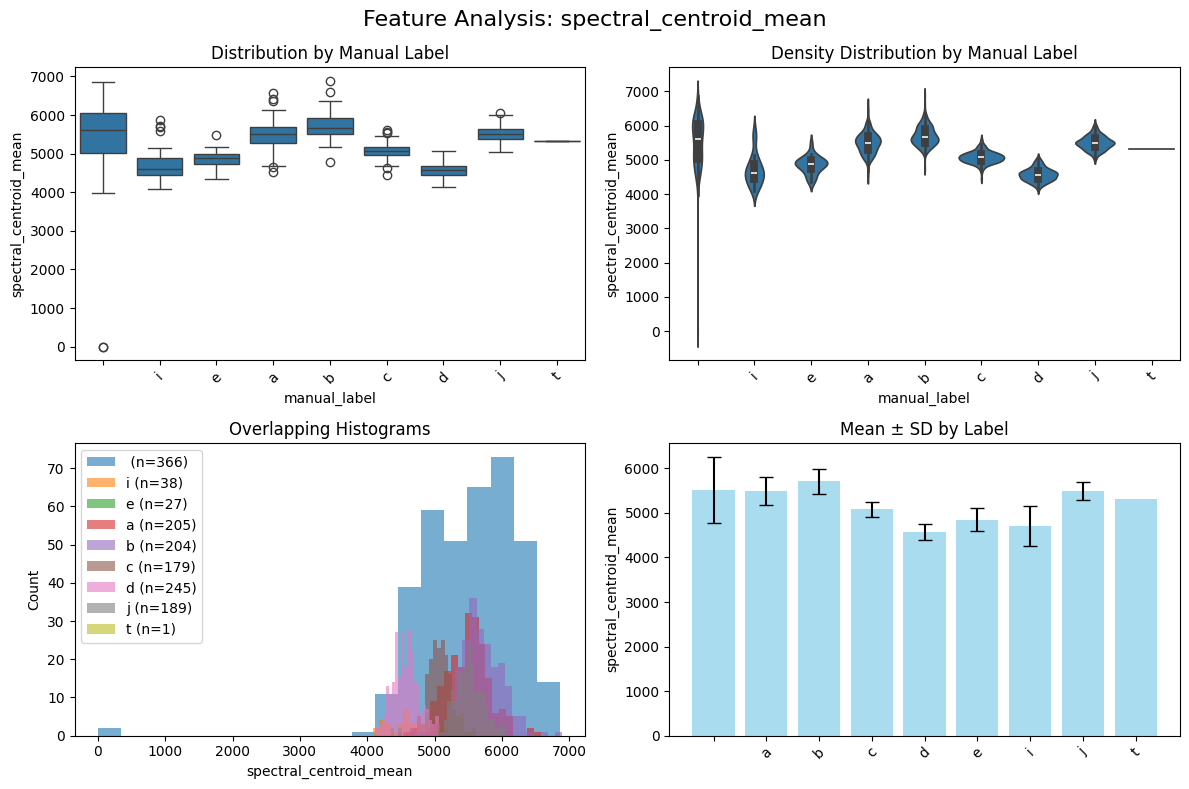

In [14]:
def analyze_feature_by_manual_label(df, feature, exclude_labels=['None'], figsize=(12, 8)):
    """
    Analyze distribution of a single feature across manual labels.

    Args:
        df: DataFrame with syllable data
        feature: Feature column name to analyze
        exclude_labels: Manual labels to exclude from analysis
        figsize: Figure size for plots
    """
    # Filter data
    analysis_df = df[~df['manual_label'].isin(exclude_labels)].copy()

    if analysis_df.empty:
        print(f"No data available for feature {feature} after filtering")
        return

    # Remove NaN values for this feature
    analysis_df = analysis_df.dropna(subset=[feature])

    if analysis_df.empty:
        print(f"No valid data for feature {feature}")
        return

    print(f"\n=== Analysis for {feature} ===")
    print(f"Valid syllables: {len(analysis_df)}")

    # Summary statistics by label
    summary_stats = analysis_df.groupby('manual_label')[feature].agg([
        'count', 'mean', 'std', 'min', 'max', 'median'
    ]).round(3)
    print(f"\nSummary statistics by manual label:")
    print(summary_stats)

    # Statistical tests (ANOVA)
    labels = analysis_df['manual_label'].unique()
    if len(labels) > 1:
        groups = [analysis_df[analysis_df['manual_label'] == label][feature].values
                 for label in labels]
        groups = [group for group in groups if len(group) > 0]  # Remove empty groups

        if len(groups) > 1:
            f_stat, p_value = stats.f_oneway(*groups)
            print(f"\nANOVA F-statistic: {f_stat:.3f}, p-value: {p_value:.6f}")
            if p_value < 0.001:
                print("*** Highly significant differences between labels")
            elif p_value < 0.01:
                print("** Significant differences between labels")
            elif p_value < 0.05:
                print("* Marginally significant differences between labels")
            else:
                print("No significant differences between labels")

    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f'Feature Analysis: {feature}', fontsize=16)

    # 1. Box plot
    sns.boxplot(data=analysis_df, x='manual_label', y=feature, ax=axes[0,0])
    axes[0,0].set_title('Distribution by Manual Label')
    axes[0,0].tick_params(axis='x', rotation=45)

    # 2. Violin plot
    sns.violinplot(data=analysis_df, x='manual_label', y=feature, ax=axes[0,1])
    axes[0,1].set_title('Density Distribution by Manual Label')
    axes[0,1].tick_params(axis='x', rotation=45)

    # 3. Histogram with overlays
    for label in labels:
        label_data = analysis_df[analysis_df['manual_label'] == label][feature]
        axes[1,0].hist(label_data, alpha=0.6, label=f'{label} (n={len(label_data)})', bins=20)
    axes[1,0].set_xlabel(feature)
    axes[1,0].set_ylabel('Count')
    axes[1,0].set_title('Overlapping Histograms')
    axes[1,0].legend()

    # 4. Mean values with error bars
    means = summary_stats['mean']
    stds = summary_stats['std']
    axes[1,1].bar(range(len(means)), means.values, yerr=stds.values,
                  capsize=5, alpha=0.7, color='skyblue')
    axes[1,1].set_xticks(range(len(means)))
    axes[1,1].set_xticklabels(means.index, rotation=45)
    axes[1,1].set_ylabel(feature)
    axes[1,1].set_title('Mean ± SD by Label')

    plt.tight_layout()
    plt.show()

    return summary_stats

# Example usage for a single feature
feature_stats = analyze_feature_by_manual_label(df, 'spectral_centroid_mean')

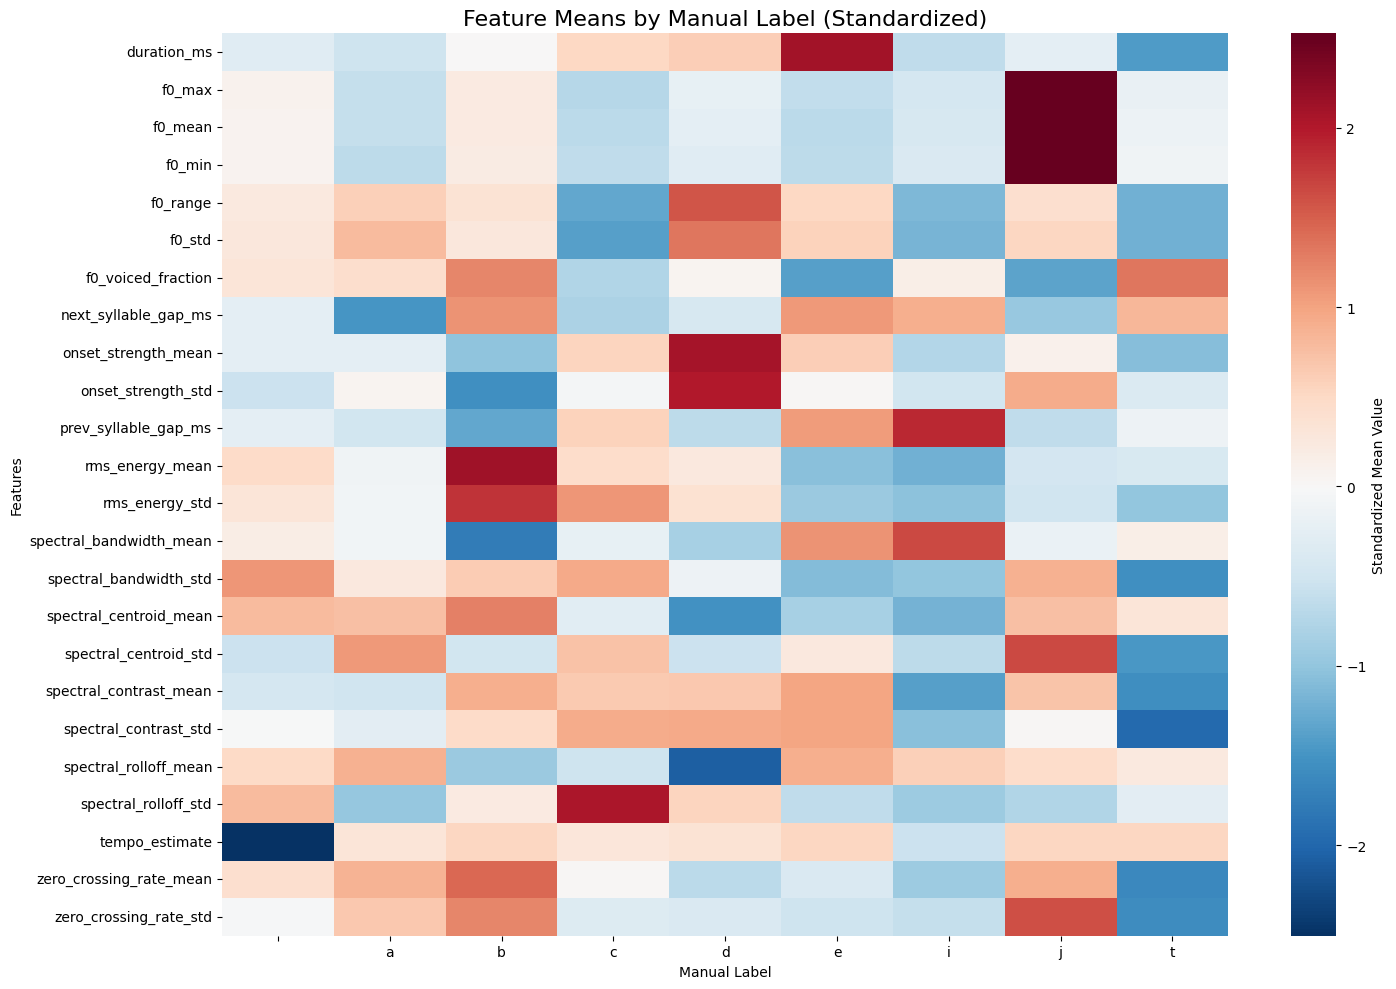

In [15]:
def create_feature_overview_heatmap(df, features=None, exclude_labels=['None'], figsize=(15, 10)):
    """
    Create a heatmap showing mean values of all features by manual label.

    Args:
        df: DataFrame with syllable data
        features: List of features to include (None = all acoustic features)
        exclude_labels: Manual labels to exclude
        figsize: Figure size
    """
    # Filter data
    analysis_df = df[~df['manual_label'].isin(exclude_labels)].copy()

    if features is None:
        features = [col for col in df.columns if col not in [
            'bird_name', 'hash_id', 'song_file', 'syllable_index', 'manual_label',
            'clustering_labels', 'position_in_song', 'song_length_syllables',
            'start_time_ms', 'end_time_ms', 'mfcc_means', 'mfcc_stds'  # Exclude complex features
        ] and not col.startswith('cluster_')]

    # Calculate mean values by label
    feature_means = analysis_df.groupby('manual_label')[features].mean()

    # Standardize features (z-score) for better visualization
    feature_means_standardized = feature_means.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

    # Create heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(feature_means_standardized.T,
                annot=False,
                cmap='RdBu_r',
                center=0,
                cbar_kws={'label': 'Standardized Mean Value'})

    plt.title('Feature Means by Manual Label (Standardized)', fontsize=16)
    plt.xlabel('Manual Label')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

    return feature_means, feature_means_standardized

# Create the overview heatmap
feature_means, feature_means_std = create_feature_overview_heatmap(df)

In [16]:
def analyze_all_features_by_label(df, features=None, exclude_labels=['None'],
                                 save_plots=False, plot_dir='feature_plots'):
    """
    Analyze all features and identify which ones show the strongest differences between labels.

    Args:
        df: DataFrame with syllable data
        features: List of features to analyze (None = all acoustic features)
        exclude_labels: Manual labels to exclude
        save_plots: Whether to save individual plots
        plot_dir: Directory to save plots
    """
    # Filter data
    analysis_df = df[~df['manual_label'].isin(exclude_labels)].copy()

    if features is None:
        features = [col for col in df.columns if col not in [
            'bird_name', 'hash_id', 'song_file', 'syllable_index', 'manual_label',
            'clustering_labels', 'position_in_song', 'song_length_syllables',
            'start_time_ms', 'end_time_ms', 'mfcc_means', 'mfcc_stds'
        ] and not col.startswith('cluster_')]

    if save_plots:
        import os
        os.makedirs(plot_dir, exist_ok=True)

    # Store results
    results = []

    print("Analyzing all features...")
    for feature in tqdm(features):
        try:
            # Remove NaN values
            feature_df = analysis_df.dropna(subset=[feature])

            if len(feature_df) == 0:
                continue

            # Get unique labels for this feature
            labels = feature_df['manual_label'].unique()

            if len(labels) < 2:
                continue

            # ANOVA test
            groups = [feature_df[feature_df['manual_label'] == label][feature].values
                     for label in labels]
            groups = [group for group in groups if len(group) > 0]

            if len(groups) < 2:
                continue

            f_stat, p_value = stats.f_oneway(*groups)

            # Calculate effect size (eta-squared)
            # eta² = SS_between / SS_total
            overall_mean = feature_df[feature].mean()
            ss_total = ((feature_df[feature] - overall_mean) ** 2).sum()

            ss_between = 0
            for label in labels:
                group_data = feature_df[feature_df['manual_label'] == label][feature]
                if len(group_data) > 0:
                    group_mean = group_data.mean()
                    ss_between += len(group_data) * (group_mean - overall_mean) ** 2

            eta_squared = ss_between / ss_total if ss_total > 0 else 0

            # Summary statistics
            summary_stats = feature_df.groupby('manual_label')[feature].agg([
                'count', 'mean', 'std'
            ])

            results.append({
                'feature': feature,
                'f_statistic': f_stat,
                'p_value': p_value,
                'eta_squared': eta_squared,
                'n_syllables': len(feature_df),
                'n_labels': len(labels),
                'mean_by_label': summary_stats['mean'].to_dict(),
                'std_by_label': summary_stats['std'].to_dict()
            })

            # Create and save plot if requested
            if save_plots:
                plt.figure(figsize=(10, 6))
                sns.boxplot(data=feature_df, x='manual_label', y=feature)
                plt.title(f'{feature}\nF={f_stat:.3f}, p={p_value:.6f}, η²={eta_squared:.3f}')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.savefig(os.path.join(plot_dir, f'{feature}_boxplot.png'), dpi=300, bbox_inches='tight')
                plt.close()

        except Exception as e:
            print(f"Error analyzing {feature}: {e}")
            continue

    # Convert to DataFrame and sort by effect size
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('eta_squared', ascending=False)

    return results_df

# Run comprehensive analysis
print("Running comprehensive feature analysis...")
feature_analysis_results = analyze_all_features_by_label(df, save_plots=False)

# Display top features that discriminate between labels
print("\n=== Top 10 Features for Discriminating Manual Labels ===")
top_features = feature_analysis_results.head(10)
for idx, row in top_features.iterrows():
    significance = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
    print(f"{row['feature']:<30} η²={row['eta_squared']:.3f}, p={row['p_value']:.6f} {significance}")

Running comprehensive feature analysis...
Analyzing all features...


100%|██████████| 24/24 [00:00<00:00, 37.39it/s]


=== Top 10 Features for Discriminating Manual Labels ===
duration_ms                    η²=0.586, p=0.000000 ***
f0_min                         η²=0.577, p=0.000000 ***
f0_mean                        η²=0.572, p=0.000000 ***
f0_max                         η²=0.563, p=0.000000 ***
onset_strength_mean            η²=0.528, p=0.000000 ***
spectral_centroid_mean         η²=0.455, p=0.000000 ***
zero_crossing_rate_std         η²=0.443, p=0.000000 ***
spectral_contrast_mean         η²=0.430, p=0.000000 ***
rms_energy_mean                η²=0.404, p=0.000000 ***
rms_energy_std                 η²=0.390, p=0.000000 ***


In [17]:
def create_interactive_feature_explorer(df, exclude_labels=['None']):
    """
    Create an interactive widget to explore different features.
    """
    from ipywidgets import interact, Dropdown

    # Get available features
    features = [col for col in df.columns if col not in [
        'bird_name', 'hash_id', 'song_file', 'syllable_index', 'manual_label',
        'clustering_labels', 'position_in_song', 'song_length_syllables',
        'start_time_ms', 'end_time_ms', 'mfcc_means', 'mfcc_stds'
    ] and not col.startswith('cluster_')]

    def plot_feature(feature_name):
        analyze_feature_by_manual_label(df, feature_name, exclude_labels=exclude_labels)

    # Create interactive dropdown
    feature_dropdown = Dropdown(
        options=features,
        value=features[0],
        description='Feature:'
    )

    interact(plot_feature, feature_name=feature_dropdown)

# Uncomment to use interactive explorer (requires ipywidgets)
# create_interactive_feature_explorer(df)

=== MFCC Means Analysis ===
MFCC  1: F=26.816, p=0.000000, η²=0.129 ***
MFCC  2: F=233.282, p=0.000000, η²=0.564 ***
MFCC  3: F=292.004, p=0.000000, η²=0.618 ***
MFCC  4: F=221.077, p=0.000000, η²=0.550 ***
MFCC  5: F=254.471, p=0.000000, η²=0.585 ***
MFCC  6: F=66.650, p=0.000000, η²=0.270 ***
MFCC  7: F=66.103, p=0.000000, η²=0.268 ***
MFCC  8: F=111.471, p=0.000000, η²=0.382 ***
MFCC  9: F=185.802, p=0.000000, η²=0.507 ***
MFCC 10: F=186.873, p=0.000000, η²=0.509 ***
MFCC 11: F=191.989, p=0.000000, η²=0.515 ***
MFCC 12: F=185.383, p=0.000000, η²=0.507 ***
MFCC 13: F=266.441, p=0.000000, η²=0.596 ***


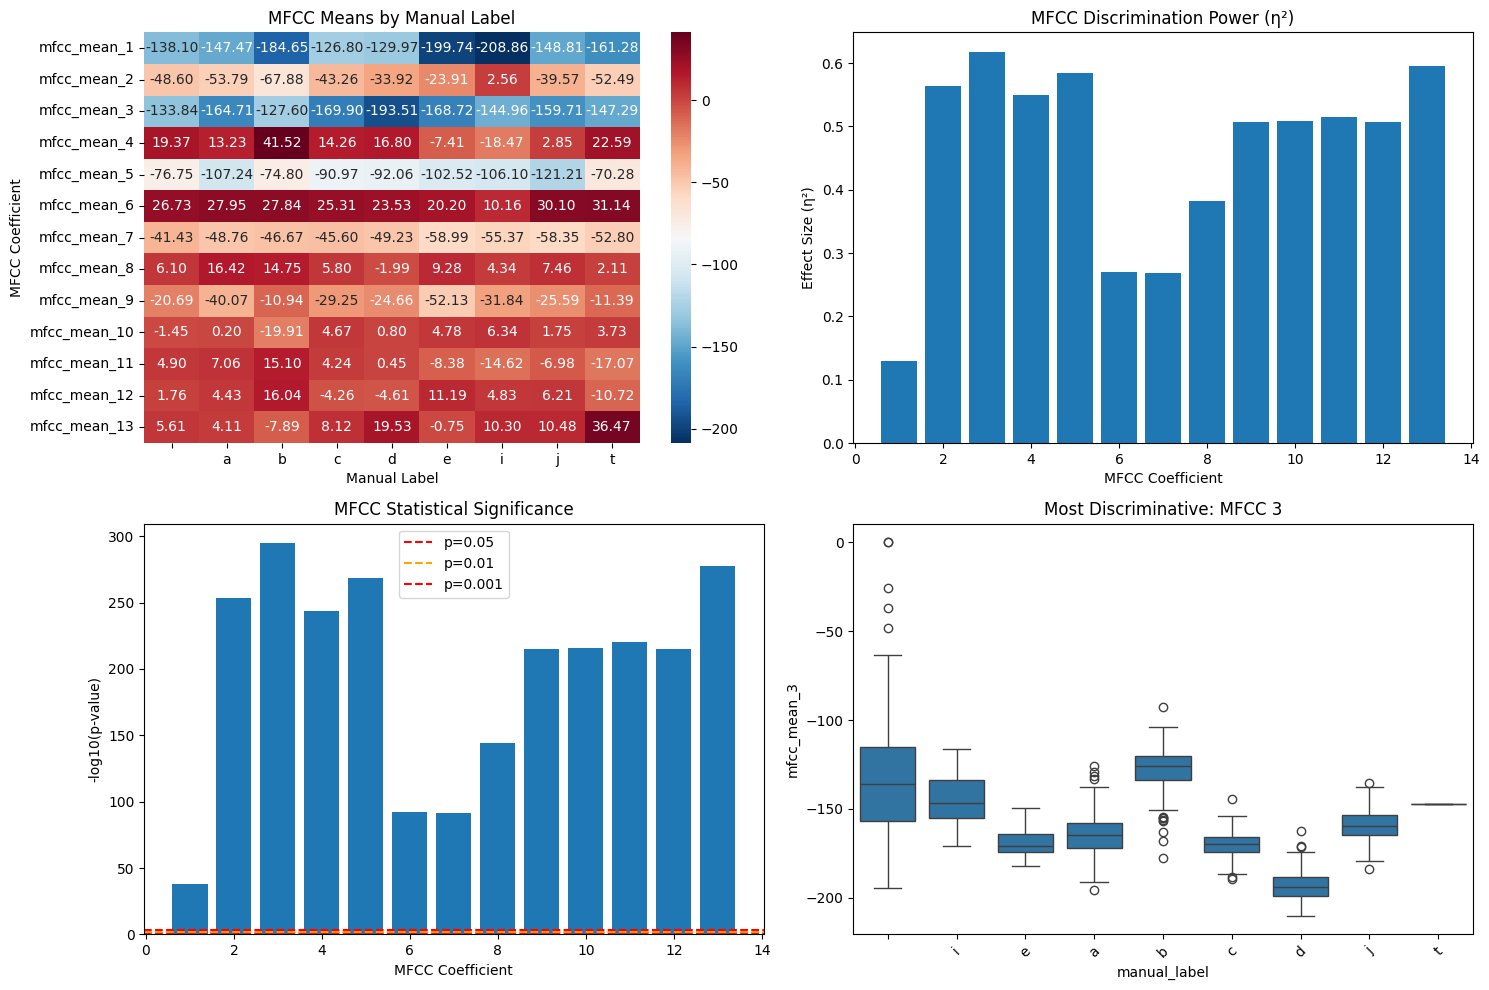

In [18]:
def analyze_mfcc_features(df, exclude_labels=['None']):
    """
    Special analysis for MFCC features which are stored as lists.
    """
    # Filter data
    analysis_df = df[~df['manual_label'].isin(exclude_labels)].copy()
    analysis_df = analysis_df.dropna(subset=['mfcc_means', 'mfcc_stds'])

    if analysis_df.empty:
        print("No MFCC data available")
        return

    # Convert MFCC lists to separate columns
    mfcc_means_df = pd.DataFrame(analysis_df['mfcc_means'].tolist(),
                                columns=[f'mfcc_mean_{i+1}' for i in range(13)])
    mfcc_stds_df = pd.DataFrame(analysis_df['mfcc_stds'].tolist(),
                               columns=[f'mfcc_std_{i+1}' for i in range(13)])

    # Add manual labels
    mfcc_means_df['manual_label'] = analysis_df['manual_label'].values
    mfcc_stds_df['manual_label'] = analysis_df['manual_label'].values

    # Analyze each MFCC coefficient
    print("=== MFCC Means Analysis ===")
    mfcc_results = []

    for i in range(1, 14):
        feature = f'mfcc_mean_{i}'

        # ANOVA test
        labels = mfcc_means_df['manual_label'].unique()
        groups = [mfcc_means_df[mfcc_means_df['manual_label'] == label][feature].values
                 for label in labels]

        f_stat, p_value = stats.f_oneway(*groups)

        # Effect size
        overall_mean = mfcc_means_df[feature].mean()
        ss_total = ((mfcc_means_df[feature] - overall_mean) ** 2).sum()

        ss_between = 0
        for label in labels:
            group_data = mfcc_means_df[mfcc_means_df['manual_label'] == label][feature]
            group_mean = group_data.mean()
            ss_between += len(group_data) * (group_mean - overall_mean) ** 2

        eta_squared = ss_between / ss_total if ss_total > 0 else 0

        mfcc_results.append({
            'coefficient': i,
            'f_statistic': f_stat,
            'p_value': p_value,
            'eta_squared': eta_squared
        })

        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        print(f"MFCC {i:2d}: F={f_stat:6.3f}, p={p_value:.6f}, η²={eta_squared:.3f} {significance}")

    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. MFCC means heatmap
    mfcc_means_by_label = mfcc_means_df.groupby('manual_label')[[f'mfcc_mean_{i+1}' for i in range(13)]].mean()
    sns.heatmap(mfcc_means_by_label.T, annot=True, fmt='.2f', cmap='RdBu_r', ax=axes[0,0])
    axes[0,0].set_title('MFCC Means by Manual Label')
    axes[0,0].set_xlabel('Manual Label')
    axes[0,0].set_ylabel('MFCC Coefficient')

    # 2. Effect sizes
    mfcc_results_df = pd.DataFrame(mfcc_results)
    axes[0,1].bar(mfcc_results_df['coefficient'], mfcc_results_df['eta_squared'])
    axes[0,1].set_title('MFCC Discrimination Power (η²)')
    axes[0,1].set_xlabel('MFCC Coefficient')
    axes[0,1].set_ylabel('Effect Size (η²)')

    # 3. P-values
    axes[1,0].bar(mfcc_results_df['coefficient'], -np.log10(mfcc_results_df['p_value']))
    axes[1,0].axhline(y=-np.log10(0.05), color='r', linestyle='--', label='p=0.05')
    axes[1,0].axhline(y=-np.log10(0.01), color='orange', linestyle='--', label='p=0.01')
    axes[1,0].axhline(y=-np.log10(0.001), color='red', linestyle='--', label='p=0.001')
    axes[1,0].set_title('MFCC Statistical Significance')
    axes[1,0].set_xlabel('MFCC Coefficient')
    axes[1,0].set_ylabel('-log10(p-value)')
    axes[1,0].legend()

    # 4. Box plot of most discriminative MFCC
    best_mfcc_idx = mfcc_results_df.loc[mfcc_results_df['eta_squared'].idxmax(), 'coefficient']
    best_mfcc_feature = f'mfcc_mean_{best_mfcc_idx}'
    sns.boxplot(data=mfcc_means_df, x='manual_label', y=best_mfcc_feature, ax=axes[1,1])
    axes[1,1].set_title(f'Most Discriminative: MFCC {best_mfcc_idx}')
    axes[1,1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return mfcc_results_df, mfcc_means_df, mfcc_stds_df

# Analyze MFCC features
mfcc_analysis = analyze_mfcc_features(df)

Generating comprehensive feature summary...
=== SYLLABLE DATABASE FEATURE SUMMARY ===

=== Database Overview ===
Total syllables: 1454
Total columns: 108

Manual label distribution:
  : 366 syllables (25.2%)
  d: 245 syllables (16.9%)
  a: 205 syllables (14.1%)
  b: 204 syllables (14.0%)
  j: 189 syllables (13.0%)
  c: 179 syllables (12.3%)
  i: 38 syllables (2.6%)
  e: 27 syllables (1.9%)
  t: 1 syllables (0.1%)

Acoustic features available: 26

Features with missing data:
  f0_max: 254 missing (17.5%)
  f0_mean: 254 missing (17.5%)
  f0_min: 254 missing (17.5%)
  f0_range: 254 missing (17.5%)
  f0_std: 254 missing (17.5%)
  next_syllable_gap_ms: 24 missing (1.7%)
  prev_syllable_gap_ms: 24 missing (1.7%)

Analyzing feature discrimination power...
Analyzing all features...


 31%|███       | 8/26 [00:00<00:00, 54.94it/s]

Error analyzing mfcc_means: unsupported operand type(s) for /: 'list' and 'int'
Error analyzing mfcc_stds: unsupported operand type(s) for /: 'list' and 'int'


100%|██████████| 26/26 [00:00<00:00, 39.95it/s]



=== TOP 15 MOST DISCRIMINATIVE FEATURES ===
(Features that best separate manual labels)

 1. duration_ms                   
    Effect Size (η²): 0.5862 (Large)
    Significance: p = 0.000000 ***
    Sample size: 1454 syllables across 9 labels
    Means by label: =78.164 a=73.111 b=85.614 c=98.028 d=100.150 e=135.733 i=70.185 j=79.496 t=51.375 

 2. f0_min                        
    Effect Size (η²): 0.5768 (Large)
    Significance: p = 0.000000 ***
    Sample size: 1200 syllables across 9 labels
    Means by label: =2729.607 a=1537.867 b=2919.221 c=1555.200 d=2098.829 e=1515.090 i=1969.151 j=6697.411 t=2427.887 

 3. f0_mean                       
    Effect Size (η²): 0.5715 (Large)
    Significance: p = 0.000000 ***
    Sample size: 1200 syllables across 9 labels
    Means by label: =2832.914 a=1702.733 b=3052.252 c=1563.614 d=2281.443 e=1591.192 i=1987.788 j=6779.550 t=2434.939 

 4. f0_max                        
    Effect Size (η²): 0.5633 (Large)
    Significance: p = 0.00000

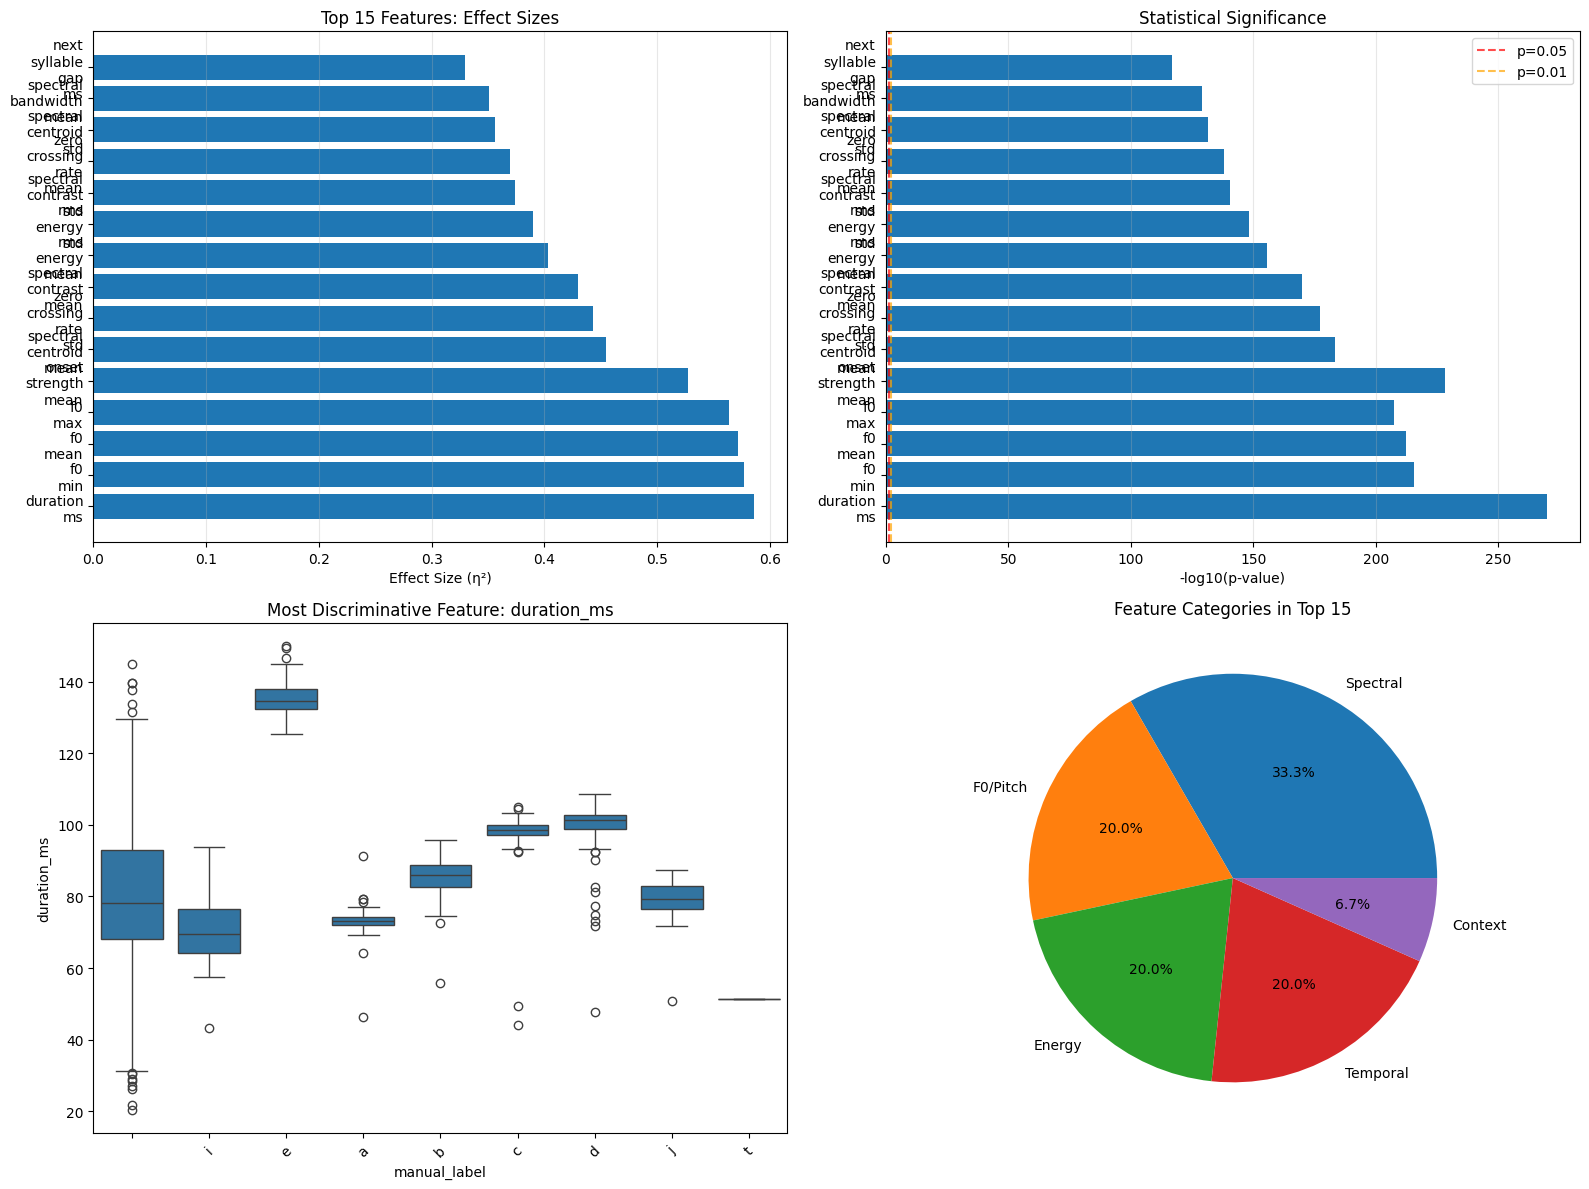

=== SUMMARY STATISTICS ===
Total features analyzed: 24
Statistically significant (p < 0.05): 24 (100.0%)
Highly significant (p < 0.001): 24 (100.0%)
Large effect size (η² ≥ 0.14): 23 (95.8%)


In [19]:
def quick_feature_summary(df, top_n=10):
    """
    Generate a quick summary of the most important features for discriminating manual labels.
    """
    print("=== SYLLABLE DATABASE FEATURE SUMMARY ===\n")

    # Basic info
    acoustic_features = explore_database_structure(df)

    # Run comprehensive analysis
    print("\nAnalyzing feature discrimination power...")
    feature_results = analyze_all_features_by_label(df, features=acoustic_features)

    # Display top discriminative features
    print(f"\n=== TOP {top_n} MOST DISCRIMINATIVE FEATURES ===")
    print("(Features that best separate manual labels)\n")

    top_features = feature_results.head(top_n)

    for i, (idx, row) in enumerate(top_features.iterrows(), 1):
        # Significance markers
        if row['p_value'] < 0.001:
            sig = "***"
        elif row['p_value'] < 0.01:
            sig = "**"
        elif row['p_value'] < 0.05:
            sig = "*"
        else:
            sig = ""

        # Effect size interpretation
        if row['eta_squared'] >= 0.14:
            effect = "Large"
        elif row['eta_squared'] >= 0.06:
            effect = "Medium"
        elif row['eta_squared'] >= 0.01:
            effect = "Small"
        else:
            effect = "Negligible"

        print(f"{i:2d}. {row['feature']:<30}")
        print(f"    Effect Size (η²): {row['eta_squared']:.4f} ({effect})")
        print(f"    Significance: p = {row['p_value']:.6f} {sig}")
        print(f"    Sample size: {row['n_syllables']} syllables across {row['n_labels']} labels")

        # Show means by label
        means = row['mean_by_label']
        print(f"    Means by label: ", end="")
        for label, mean_val in means.items():
            print(f"{label}={mean_val:.3f} ", end="")
        print("\n")

    # Create summary visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Effect sizes bar plot
    axes[0,0].barh(range(len(top_features)), top_features['eta_squared'].values)
    axes[0,0].set_yticks(range(len(top_features)))
    axes[0,0].set_yticklabels([f.replace('_', '\n') for f in top_features['feature'].values])
    axes[0,0].set_xlabel('Effect Size (η²)')
    axes[0,0].set_title(f'Top {top_n} Features: Effect Sizes')
    axes[0,0].grid(axis='x', alpha=0.3)

    # 2. P-values (negative log scale)
    log_p_values = -np.log10(top_features['p_value'].values)
    axes[0,1].barh(range(len(top_features)), log_p_values)
    axes[0,1].set_yticks(range(len(top_features)))
    axes[0,1].set_yticklabels([f.replace('_', '\n') for f in top_features['feature'].values])
    axes[0,1].set_xlabel('-log10(p-value)')
    axes[0,1].set_title('Statistical Significance')
    axes[0,1].axvline(x=-np.log10(0.05), color='r', linestyle='--', alpha=0.7, label='p=0.05')
    axes[0,1].axvline(x=-np.log10(0.01), color='orange', linestyle='--', alpha=0.7, label='p=0.01')
    axes[0,1].legend()
    axes[0,1].grid(axis='x', alpha=0.3)

    # 3. Box plot of most discriminative feature
    best_feature = top_features.iloc[0]['feature']
    filtered_df = df[~df['manual_label'].isin(['None'])].dropna(subset=[best_feature])
    sns.boxplot(data=filtered_df, x='manual_label', y=best_feature, ax=axes[1,0])
    axes[1,0].set_title(f'Most Discriminative Feature: {best_feature}')
    axes[1,0].tick_params(axis='x', rotation=45)

    # 4. Feature category breakdown
    feature_categories = {
        'Spectral': ['spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'spectral_contrast'],
        'F0/Pitch': ['f0_mean', 'f0_std', 'f0_min', 'f0_max', 'f0_range', 'f0_voiced_fraction'],
        'Energy': ['rms_energy', 'onset_strength'],
        'Temporal': ['duration_ms', 'tempo_estimate', 'zero_crossing_rate'],
        'Context': ['prev_syllable_gap', 'next_syllable_gap']
    }

    category_counts = {}
    for category, keywords in feature_categories.items():
        count = sum(1 for feature in top_features['feature']
                   if any(keyword in feature for keyword in keywords))
        category_counts[category] = count

    # Add "Other" category
    total_categorized = sum(category_counts.values())
    if total_categorized < len(top_features):
        category_counts['Other'] = len(top_features) - total_categorized

    # Remove categories with zero counts
    category_counts = {k: v for k, v in category_counts.items() if v > 0}

    axes[1,1].pie(category_counts.values(), labels=category_counts.keys(), autopct='%1.1f%%')
    axes[1,1].set_title(f'Feature Categories in Top {top_n}')

    plt.tight_layout()
    plt.show()

    # Summary statistics
    print("=== SUMMARY STATISTICS ===")
    significant_features = feature_results[feature_results['p_value'] < 0.05]
    highly_significant = feature_results[feature_results['p_value'] < 0.001]
    large_effect = feature_results[feature_results['eta_squared'] >= 0.14]

    print(f"Total features analyzed: {len(feature_results)}")
    print(f"Statistically significant (p < 0.05): {len(significant_features)} ({len(significant_features)/len(feature_results)*100:.1f}%)")
    print(f"Highly significant (p < 0.001): {len(highly_significant)} ({len(highly_significant)/len(feature_results)*100:.1f}%)")
    print(f"Large effect size (η² ≥ 0.14): {len(large_effect)} ({len(large_effect)/len(feature_results)*100:.1f}%)")

    return feature_results, top_features

# Run the comprehensive summary
print("Generating comprehensive feature summary...")
all_results, top_discriminative = quick_feature_summary(df, top_n=15)

In [20]:
# Load your data
bird_path = os.path.join('/Volumes', 'Extreme SSD', 'evsong test', 'or18or24')
db = SyllableDatabase(bird_path)
df = db.load_database()

# 1. Quick overview
acoustic_features = explore_database_structure(df)

# 2. Analyze a specific feature in detail
spectral_stats = analyze_feature_by_manual_label(df, 'spectral_centroid_mean')
duration_stats = analyze_feature_by_manual_label(df, 'duration_ms')
f0_stats = analyze_feature_by_manual_label(df, 'f0_mean')

# 3. Get overview of all features
feature_means, feature_means_std = create_feature_overview_heatmap(df)

# 4. Run comprehensive analysis to find best discriminating features
all_results, top_features = quick_feature_summary(df, top_n=15)

# 5. Analyze MFCC features specifically
mfcc_results, mfcc_means_df, mfcc_stds_df = analyze_mfcc_features(df)

# 6. Look at specific comparisons
print("\n=== COMPARING SPECIFIC LABELS ===")
# Compare just two labels
subset_df = df[df['manual_label'].isin(['a', 'b'])].copy()
if len(subset_df) > 0:
    analyze_feature_by_manual_label(subset_df, 'spectral_centroid_mean', exclude_labels=[])

# 7. Export results for further analysis
print("Saving results...")
all_results.to_csv('feature_discrimination_analysis.csv', index=False)
feature_means.to_csv('feature_means_by_label.csv')

# 8. Create custom analysis for specific feature groups
def analyze_feature_group(df, feature_group_name, feature_list, exclude_labels=['None']):
    """Analyze a specific group of related features."""
    print(f"\n=== {feature_group_name.upper()} FEATURES ===")

    group_results = []
    for feature in feature_list:
        if feature in df.columns:
            # Quick stats
            analysis_df = df[~df['manual_label'].isin(exclude_labels)].dropna(subset=[feature])
            if len(analysis_df) > 0:
                labels = analysis_df['manual_label'].unique()
                if len(labels) > 1:
                    groups = [analysis_df[analysis_df['manual_label'] == label][feature].values
                             for label in labels]
                    f_stat, p_value = stats.f_oneway(*groups)

                    group_results.append({
                        'feature': feature,
                        'f_stat': f_stat,
                        'p_value': p_value,
                        'significant': p_value < 0.05
                    })

    # Sort by F-statistic
    group_results.sort(key=lambda x: x['f_stat'], reverse=True)

    print(f"Found {len(group_results)} features in {feature_group_name} group:")
    for result in group_results:
        sig_marker = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else ""
        print(f"  {result['feature']:<25} F={result['f_stat']:6.2f}, p={result['p_value']:.4f} {sig_marker}")

    return group_results

# Analyze feature groups
spectral_features = [col for col in df.columns if 'spectral' in col]
f0_features = [col for col in df.columns if 'f0_' in col]
energy_features = [col for col in df.columns if any(x in col for x in ['rms_energy', 'onset_strength'])]
temporal_features = ['duration_ms', 'tempo_estimate', 'zero_crossing_rate_mean', 'zero_crossing_rate_std']

spectral_analysis = analyze_feature_group(df, "Spectral", spectral_features)
f0_analysis = analyze_feature_group(df, "Fundamental Frequency", f0_features)
energy_analysis = analyze_feature_group(df, "Energy", energy_features)
temporal_analysis = analyze_feature_group(df, "Temporal", temporal_features)

=== Database Overview ===
Total syllables: 1454
Total columns: 108

Manual label distribution:
  : 366 syllables (25.2%)
  d: 245 syllables (16.9%)
  a: 205 syllables (14.1%)
  b: 204 syllables (14.0%)
  j: 189 syllables (13.0%)
  c: 179 syllables (12.3%)
  i: 38 syllables (2.6%)
  e: 27 syllables (1.9%)
  t: 1 syllables (0.1%)

Acoustic features available: 26

Features with missing data:
  f0_max: 254 missing (17.5%)
  f0_mean: 254 missing (17.5%)
  f0_min: 254 missing (17.5%)
  f0_range: 254 missing (17.5%)
  f0_std: 254 missing (17.5%)
  next_syllable_gap_ms: 24 missing (1.7%)
  prev_syllable_gap_ms: 24 missing (1.7%)



=== MANUAL vs AUTOMATIC CLUSTERING COMPARISON ===
Automatic method: cluster_rank0_unknown_n50_d0p1_cs60_s5_euclidean
Comparing 1454 syllables
Manual labels: ['', 'a', 'b', 'c', 'd', 'e', 'i', 'j', 't']
Automatic clusters: [np.int64(0), np.int64(1), np.int64(2)]

Features where manual labels discriminate better: 11
Features where automatic clustering discriminates better: 13

Top 5 features for manual labels:
  1. duration_ms                    F=255.90
  2. f0_min                         F=202.94
  3. onset_strength_mean            F=201.66
  4. f0_mean                        F=198.58
  5. f0_max                         F=192.05

Top 5 features for automatic clustering:
  1. duration_ms                    F=1921.97
  2. spectral_contrast_std          F=983.19
  3. onset_strength_mean            F=627.03
  4. spectral_contrast_mean         F=595.09
  5. zero_crossing_rate_std         F=546.13


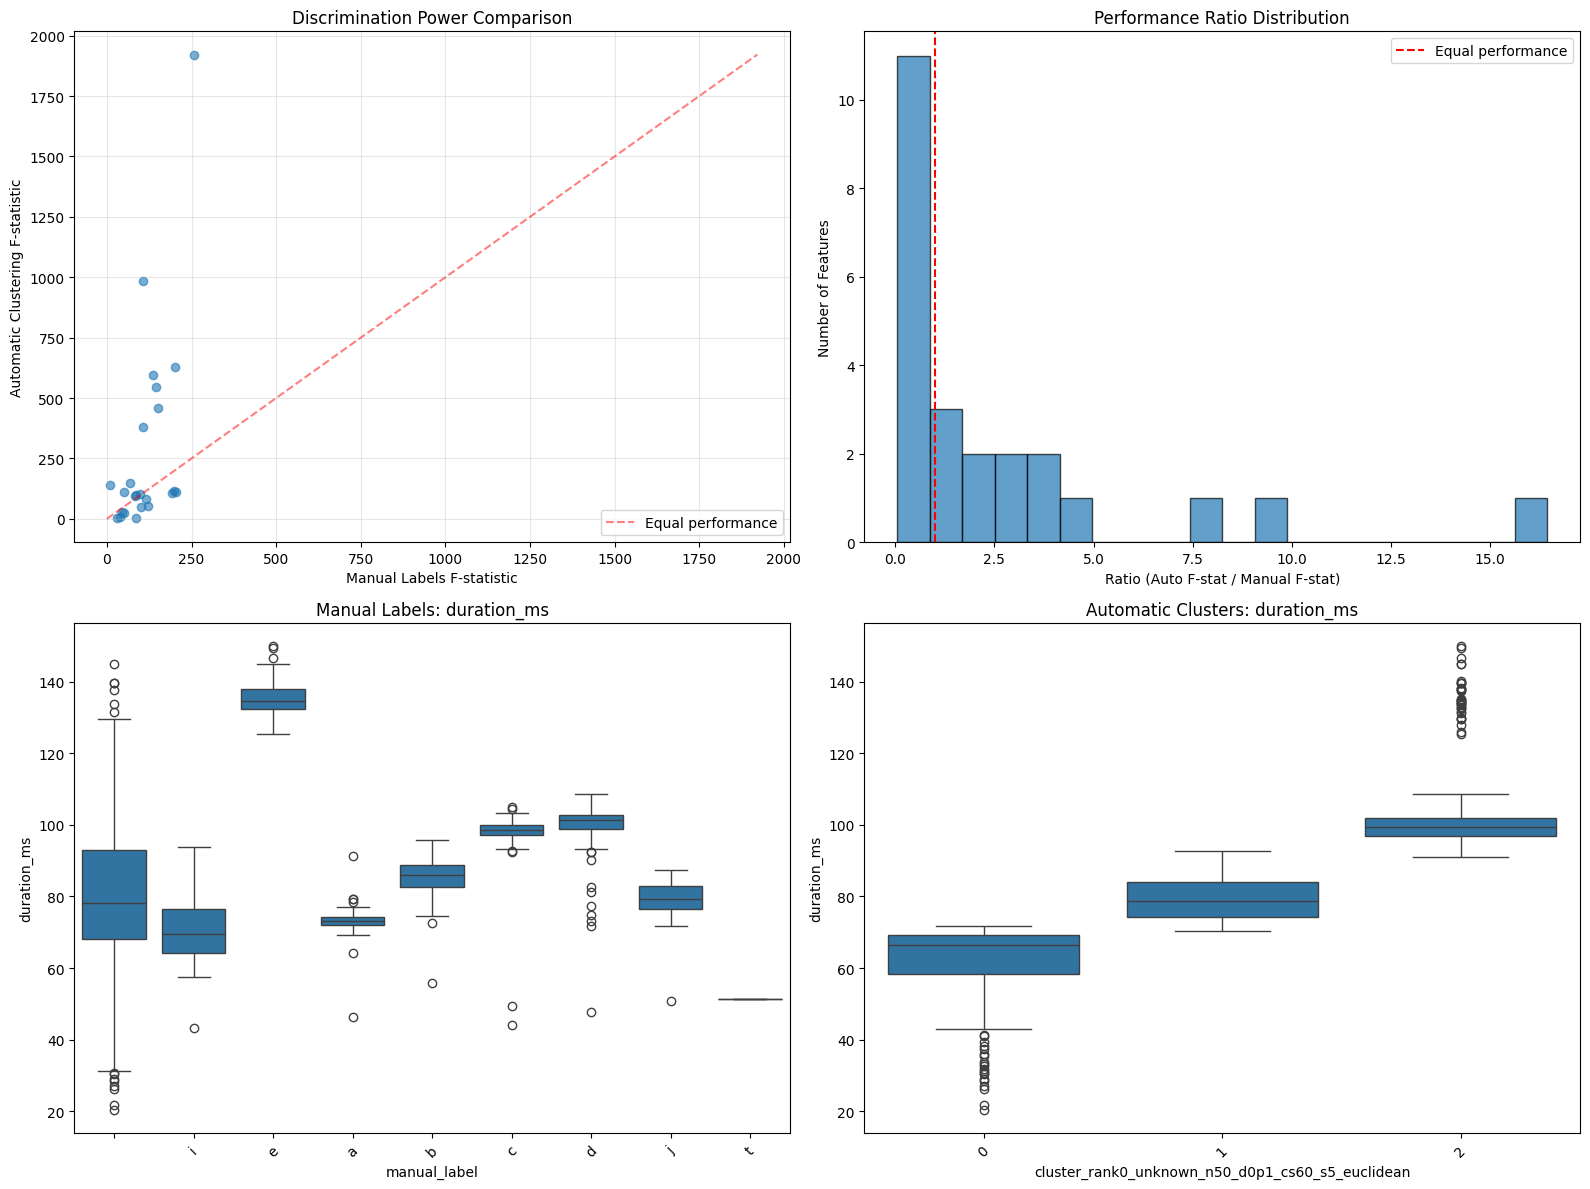


Agreement between manual and automatic labels:
  Adjusted Rand Index: 0.217 (1.0 = perfect agreement, 0.0 = random)
  Normalized Mutual Information: 0.396 (1.0 = perfect agreement)


In [21]:
def compare_manual_vs_automatic_clustering(df, clustering_method='cluster_rank0_unknown_n50_d0p1_cs60_s5_euclidean'):
    """
    Compare how well manual labels vs automatic clustering separate the acoustic space.
    """
    print(f"\n=== MANUAL vs AUTOMATIC CLUSTERING COMPARISON ===")
    print(f"Automatic method: {clustering_method}")

    # Filter data
    comparison_df = df[
        (df['manual_label'].notna()) &
        (df['manual_label'] != 'None') &
        (df[clustering_method].notna()) &
        (df[clustering_method] != -1)
    ].copy()

    if len(comparison_df) == 0:
        print("No data available for comparison")
        return

    print(f"Comparing {len(comparison_df)} syllables")
    print(f"Manual labels: {sorted(comparison_df['manual_label'].unique())}")
    print(f"Automatic clusters: {sorted(comparison_df[clustering_method].unique())}")

    # Get acoustic features
    acoustic_features = [col for col in df.columns if col not in [
        'bird_name', 'hash_id', 'song_file', 'syllable_index', 'manual_label',
        'clustering_labels', 'position_in_song', 'song_length_syllables',
        'start_time_ms', 'end_time_ms', 'mfcc_means', 'mfcc_stds'
    ] and not col.startswith('cluster_')]

    # Compare discrimination power
    manual_scores = []
    auto_scores = []

    for feature in acoustic_features:
        feature_df = comparison_df.dropna(subset=[feature])

        if len(feature_df) < 10:  # Skip if too few samples
            continue

        # Manual labels
        manual_labels = feature_df['manual_label'].unique()
        if len(manual_labels) > 1:
            manual_groups = [feature_df[feature_df['manual_label'] == label][feature].values
                           for label in manual_labels]
            manual_f, manual_p = stats.f_oneway(*manual_groups)
            manual_scores.append({'feature': feature, 'f_stat': manual_f, 'p_value': manual_p})

        # Automatic clusters
        auto_labels = feature_df[clustering_method].unique()
        if len(auto_labels) > 1:
            auto_groups = [feature_df[feature_df[clustering_method] == label][feature].values
                          for label in auto_labels]
            auto_f, auto_p = stats.f_oneway(*auto_groups)
            auto_scores.append({'feature': feature, 'f_stat': auto_f, 'p_value': auto_p})

    # Convert to DataFrames
    manual_df = pd.DataFrame(manual_scores).sort_values('f_stat', ascending=False)
    auto_df = pd.DataFrame(auto_scores).sort_values('f_stat', ascending=False)

    # Merge for comparison
    comparison = manual_df.merge(auto_df, on='feature', suffixes=('_manual', '_auto'))
    comparison['manual_better'] = comparison['f_stat_manual'] > comparison['f_stat_auto']
    comparison['ratio'] = comparison['f_stat_auto'] / comparison['f_stat_manual']

    # Summary
    print(f"\nFeatures where manual labels discriminate better: {comparison['manual_better'].sum()}")
    print(f"Features where automatic clustering discriminates better: {(~comparison['manual_better']).sum()}")

    # Show top features for each method
    print(f"\nTop 5 features for manual labels:")
    for i, (_, row) in enumerate(manual_df.head(5).iterrows()):
        print(f"  {i+1}. {row['feature']:<30} F={row['f_stat']:.2f}")

    print(f"\nTop 5 features for automatic clustering:")
    for i, (_, row) in enumerate(auto_df.head(5).iterrows()):
        print(f"  {i+1}. {row['feature']:<30} F={row['f_stat']:.2f}")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Scatter plot: Manual vs Auto F-statistics
    axes[0,0].scatter(comparison['f_stat_manual'], comparison['f_stat_auto'], alpha=0.6)
    axes[0,0].plot([0, max(comparison[['f_stat_manual', 'f_stat_auto']].max())],
                   [0, max(comparison[['f_stat_manual', 'f_stat_auto']].max())],
                   'r--', alpha=0.5, label='Equal performance')
    axes[0,0].set_xlabel('Manual Labels F-statistic')
    axes[0,0].set_ylabel('Automatic Clustering F-statistic')
    axes[0,0].set_title('Discrimination Power Comparison')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # 2. Ratio histogram
    axes[0,1].hist(comparison['ratio'], bins=20, alpha=0.7, edgecolor='black')
    axes[0,1].axvline(x=1, color='red', linestyle='--', label='Equal performance')
    axes[0,1].set_xlabel('Ratio (Auto F-stat / Manual F-stat)')
    axes[0,1].set_ylabel('Number of Features')
    axes[0,1].set_title('Performance Ratio Distribution')
    axes[0,1].legend()

    # 3. Side-by-side comparison of best discriminating feature
    best_feature = manual_df.iloc[0]['feature']

    # Manual labels
    sns.boxplot(data=comparison_df, x='manual_label', y=best_feature, ax=axes[1,0])
    axes[1,0].set_title(f'Manual Labels: {best_feature}')
    axes[1,0].tick_params(axis='x', rotation=45)

    # Automatic clusters
    sns.boxplot(data=comparison_df, x=clustering_method, y=best_feature, ax=axes[1,1])
    axes[1,1].set_title(f'Automatic Clusters: {best_feature}')
    axes[1,1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Confusion matrix style comparison
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

    # Calculate agreement metrics
    ari = adjusted_rand_score(comparison_df['manual_label'], comparison_df[clustering_method])
    nmi = normalized_mutual_info_score(comparison_df['manual_label'], comparison_df[clustering_method])

    print(f"\nAgreement between manual and automatic labels:")
    print(f"  Adjusted Rand Index: {ari:.3f} (1.0 = perfect agreement, 0.0 = random)")
    print(f"  Normalized Mutual Information: {nmi:.3f} (1.0 = perfect agreement)")

    return comparison, manual_df, auto_df

# Run the comparison
clustering_comparison = compare_manual_vs_automatic_clustering(df)

In [ ]:
def run_complete_syllable_analysis(bird_path, save_results=True, results_dir='analysis_results'):
    """
    Run a complete analysis of syllable features and save all results.
    """
    import os

    if save_results:
        os.makedirs(results_dir, exist_ok=True)

    print("="*60)
    print("COMPLETE SYLLABLE DATABASE ANALYSIS")
    print("="*60)

    # Load database
    print("Loading syllable database...")
    db = SyllableDatabase(bird_path)
    df = db.load_database()

    if df.empty:
        print("ERROR: Could not load database!")
        return None

    bird_name = os.path.basename(bird_path)
    print(f"Bird: {bird_name}")
    print(f"Total syllables: {len(df)}")

    # Initialize results dictionary
    results = {
        'bird_name': bird_name,
        'bird_path': bird_path,
        'total_syllables': len(df),
        'analysis_timestamp': pd.Timestamp.now().isoformat()
    }

    # 1. Basic structure analysis
    print("\n" + "="*40)
    print("1. DATABASE STRUCTURE ANALYSIS")
    print("="*40)
    acoustic_features = explore_database_structure(df)
    results['acoustic_features'] = acoustic_features
    results['n_acoustic_features'] = len(acoustic_features)

    # 2. Feature discrimination analysis
    print("\n" + "="*40)
    print("2. FEATURE DISCRIMINATION ANALYSIS")
    print("="*40)
    feature_results = analyze_all_features_by_label(df, features=acoustic_features)
    results['feature_discrimination'] = feature_results.to_dict('records')

    # Save feature results
    if save_results:
        feature_results.to_csv(os.path.join(results_dir, f'{bird_name}_feature_discrimination.csv'), index=False)

    # 3. Top discriminative features
    top_n = min(15, len(feature_results))
    top_features = feature_results.head(top_n)
    results['top_discriminative_features'] = top_features.to_dict('records')

    print(f"\nTop {top_n} most discriminative features:")
    for i, (_, row) in enumerate(top_features.iterrows(), 1):
        sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
        print(f"{i:2d}. {row['feature']:<30} η²={row['eta_squared']:.4f} {sig}")

    # 4. MFCC analysis
    print("\n" + "="*40)
    print("4. MFCC COEFFICIENT ANALYSIS")
    print("="*40)
    mfcc_results, mfcc_means_df, mfcc_stds_df = analyze_mfcc_features(df)
    results['mfcc_analysis'] = mfcc_results.to_dict('records')

    if save_results:
        mfcc_results.to_csv(os.path.join(results_dir, f'{bird_name}_mfcc_analysis.csv'), index=False)
        mfcc_means_df.to_csv(os.path.join(results_dir, f'{bird_name}_mfcc_means_by_label.csv'), index=False)

    # 5. Feature group analysis
    print("\n" + "="*40)
    print("5. FEATURE GROUP ANALYSIS")
    print("="*40)

    feature_groups = {
        'spectral': [col for col in df.columns if 'spectral' in col],
        'f0': [col for col in df.columns if 'f0_' in col],
        'energy': [col for col in df.columns if any(x in col for x in ['rms_energy', 'onset_strength'])],
        'temporal': ['duration_ms', 'tempo_estimate', 'zero_crossing_rate_mean', 'zero_crossing_rate_std'],
        'context': ['prev_syllable_gap_ms', 'next_syllable_gap_ms']
    }

    group_analyses = {}
    for group_name, group_features in feature_groups.items():
        group_analysis = analyze_feature_group(df, group_name.title(), group_features)
        group_analyses[group_name] = group_analysis

    results['feature_group_analysis'] = group_analyses

    # 6. Manual vs automatic clustering comparison
    print("\n" + "="*40)
    print("6. MANUAL vs AUTOMATIC CLUSTERING")
    print("="*40)

    # Find best clustering method
    clustering_cols = [col for col in df.columns if col.startswith('cluster_rank')]
    if clustering_cols:
        # Use rank 0 (best) method
        best_clustering = clustering_cols[0]
        comparison_results, manual_results, auto_results = compare_manual_vs_automatic_clustering(df, best_clustering)

        results['clustering_comparison'] = {
            'method_used': best_clustering,
            'comparison_results': comparison_results.to_dict('records'),
            'manual_discrimination': manual_results.to_dict('records'),
            'auto_discrimination': auto_results.to_dict('records')
        }

        if save_results:
            comparison_results.to_csv(os.path.join(results_dir, f'{bird_name}_manual_vs_auto_comparison.csv'), index=False)

    # 7. Generate summary statistics
    print("\n" + "="*40)
    print("7. SUMMARY STATISTICS")
    print("="*40)

    significant_features = feature_results[feature_results['p_value'] < 0.05]
    highly_significant = feature_results[feature_results['p_value'] < 0.001]
    large_effect = feature_results[feature_results['eta_squared'] >= 0.14]
    medium_effect = feature_results[feature_results['eta_squared'] >= 0.06]

    summary_stats = {
        'total_features_analyzed': len(feature_results),
        'significant_features': len(significant_features),
        'highly_significant_features': len(highly_significant),
        'large_effect_features': len(large_effect),
        'medium_effect_features': len(medium_effect),
        'significance_percentage': len(significant_features) / len(feature_results) * 100,
        'mean_effect_size': feature_results['eta_squared'].mean(),
        'median_effect_size': feature_results['eta_squared'].median(),
        'max_effect_size': feature_results['eta_squared'].max(),
        'best_discriminating_feature': feature_results.iloc[0]['feature'],
        'best_feature_effect_size': feature_results.iloc[0]['eta_squared']
    }

    results['summary_statistics'] = summary_stats

    print(f"Features analyzed: {summary_stats['total_features_analyzed']}")
    print(f"Statistically significant: {summary_stats['significant_features']} ({summary_stats['significance_percentage']:.1f}%)")
    print(f"Highly significant (p<0.001): {summary_stats['highly_significant_features']}")
    print(f"Large effect size (η²≥0.14): {summary_stats['large_effect_features']}")
    print(f"Medium effect size (η²≥0.06): {summary_stats['medium_effect_features']}")
    print(f"Best discriminating feature: {summary_stats['best_discriminating_feature']} (η²={summary_stats['best_feature_effect_size']:.4f})")
    print(f"Mean effect size: {summary_stats['mean_effect_size']:.4f}")

    # 8. Create comprehensive visualization
    print("\n" + "="*40)
    print("8. COMPREHENSIVE VISUALIZATION")
    print("="*40)

    # Create a mega-plot with all key visualizations
    fig = plt.figure(figsize=(20, 16))

    # Define grid layout
    gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)

    # 1. Feature overview heatmap (top row, spans 2 columns)
    ax1 = fig.add_subplot(gs[0, :2])
    filtered_df = df[~df['manual_label'].isin(['None'])].copy()
    feature_subset = acoustic_features[:15]  # Top 15 features for readability
    feature_means_viz = filtered_df.groupby('manual_label')[feature_subset].mean()
    feature_means_std_viz = feature_means_viz.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

    sns.heatmap(feature_means_std_viz.T, annot=False, cmap='RdBu_r', center=0, ax=ax1)
    ax1.set_title('Top 15 Features by Manual Label (Standardized)', fontsize=12)
    ax1.set_xlabel('Manual Label')
    ax1.set_ylabel('Features')

    # 2. Effect sizes (top row, right)
    ax2 = fig.add_subplot(gs[0, 2:])
    top_10 = feature_results.head(10)
    ax2.barh(range(len(top_10)), top_10['eta_squared'].values)
    ax2.set_yticks(range(len(top_10)))
    ax2.set_yticklabels([f.replace('_', '\n') for f in top_10['feature'].values], fontsize=8)
    ax2.set_xlabel('Effect Size (η²)')
    ax2.set_title('Top 10 Features: Effect Sizes')
    ax2.grid(axis='x', alpha=0.3)

    # 3. Best discriminating feature (second row, left)
    ax3 = fig.add_subplot(gs[1, :2])
    best_feature = feature_results.iloc[0]['feature']
    sns.boxplot(data=filtered_df.dropna(subset=[best_feature]),
                x='manual_label', y=best_feature, ax=ax3)
    ax3.set_title(f'Best Discriminating Feature: {best_feature}')
    ax3.tick_params(axis='x', rotation=45)

    # 4. MFCC discrimination power (second row, right)
    ax4 = fig.add_subplot(gs[1, 2:])
    if len(mfcc_results) > 0:
        ax4.bar(mfcc_results['coefficient'], mfcc_results['eta_squared'])
        ax4.set_xlabel('MFCC Coefficient')
        ax4.set_ylabel('Effect Size (η²)')
        ax4.set_title('MFCC Discrimination Power')

    # 5. Manual label distribution (third row, left)
    ax5 = fig.add_subplot(gs[2, 0])
    label_counts = filtered_df['manual_label'].value_counts()
    ax5.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%')
    ax5.set_title('Manual Label Distribution')

    # 6. Feature significance (third row, center-left)
    ax6 = fig.add_subplot(gs[2, 1])
    significance_bins = ['p≥0.05', '0.01≤p<0.05', '0.001≤p<0.01', 'p<0.001']
    significance_counts = [
        len(feature_results[feature_results['p_value'] >= 0.05]),
        len(feature_results[(feature_results['p_value'] >= 0.01) & (feature_results['p_value'] < 0.05)]),
        len(feature_results[(feature_results['p_value'] >= 0.001) & (feature_results['p_value'] < 0.01)]),
        len(feature_results[feature_results['p_value'] < 0.001])
    ]
    ax6.bar(significance_bins, significance_counts)
    ax6.set_title('Feature Significance Distribution')
    ax6.tick_params(axis='x', rotation=45)

    # 7. Effect size distribution (third row, center-right)
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.hist(feature_results['eta_squared'], bins=20, alpha=0.7, edgecolor='black')
    ax7.axvline(x=0.01, color='green', linestyle='--', label='Small (0.01)')
    ax7.axvline(x=0.06, color='orange', linestyle='--', label='Medium (0.06)')
    ax7.axvline(x=0.14, color='red', linestyle='--', label='Large (0.14)')
    ax7.set_xlabel('Effect Size (η²)')
    ax7.set_ylabel('Number of Features')
    ax7.set_title('Effect Size Distribution')
    ax7.legend()

    # 8. Feature category breakdown (third row, right)
    ax8 = fig.add_subplot(gs[2, 3])
    if 'feature_group_analysis' in results:
        category_counts = {}
        for category, analysis in results['feature_group_analysis'].items():
            significant_in_category = sum(1 for item in analysis if item.get('significant', False))
            category_counts[category.title()] = significant_in_category

        if category_counts:
            ax8.bar(category_counts.keys(), category_counts.values())
            ax8.set_title('Significant Features by Category')
            ax8.tick_params(axis='x', rotation=45)

    # 9. Manual vs Auto comparison (bottom row, if available)
    if 'clustering_comparison' in results:
        ax9 = fig.add_subplot(gs[3, :2])
        comparison_data = pd.DataFrame(results['clustering_comparison']['comparison_results'])
        if len(comparison_data) > 0:
            ax9.scatter(comparison_data['f_stat_manual'], comparison_data['f_stat_auto'], alpha=0.6)
            max_val = max(comparison_data[['f_stat_manual', 'f_stat_auto']].max())
            ax9.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Equal performance')
            ax9.set_xlabel('Manual Labels F-statistic')
            ax9.set_ylabel('Automatic Clustering F-statistic')
            ax9.set_title('Manual vs Automatic Discrimination')
            ax9.legend()
            ax9.grid(True, alpha=0.3)

    # 10. Summary text (bottom row, right)
    ax10 = fig.add_subplot(gs[3, 2:])
    ax10.axis('off')
    summary_text = f"""
ANALYSIS SUMMARY

Bird: {bird_name}
Total Syllables: {len(df):,}
Manual Labels: {len(filtered_df['manual_label'].unique())}

Feature Analysis:
• {summary_stats['total_features_analyzed']} features analyzed
• {summary_stats['significant_features']} significant (p<0.05)
• {summary_stats['large_effect_features']} with large effect size
• Best feature: {summary_stats['best_discriminating_feature'][:20]}...
• Max η²: {summary_stats['best_feature_effect_size']:.4f}

Quality Assessment:
• {summary_stats['significance_percentage']:.1f}% features significant
• Mean effect size: {summary_stats['mean_effect_size']:.4f}
• Manual labels show {'good' if summary_stats['mean_effect_size'] > 0.1 else 'moderate' if summary_stats['mean_effect_size'] > 0.05 else 'weak'} discrimination
"""

    ax10.text(0.1, 0.9, summary_text, fontsize=10, verticalalignment='top',
              bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))

    plt.suptitle(f'Comprehensive Syllable Analysis: {bird_name}', fontsize=16, y=0.98)

    if save_results:
        plt.savefig(os.path.join(results_dir, f'{bird_name}_comprehensive_analysis.png'),
                   dpi=300, bbox_inches='tight')
        print(f"Comprehensive visualization saved!")

    plt.show()

    # 9. Save complete results
    if save_results:
        results_file = os.path.join(results_dir, f'{bird_name}_complete_analysis.json')

        # Convert any remaining numpy types for JSON serialization
        def convert_for_json(obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, pd.DataFrame):
                return obj.to_dict('records')
            elif isinstance(obj, dict):
                return {k: convert_for_json(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [convert_for_json(item) for item in obj]
            else:
                return obj

        results_json = convert_for_json(results)

        with open(results_file, 'w') as f:
            json.dump(results_json, f, indent=2)

        print(f"Complete analysis results saved to: {results_file}")

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE!")
    print("="*60)

    return results, df, feature_results

# Usage example:
# Run complete analysis
complete_results = run_complete_syllable_analysis(bird_path, save_results=True)